In [1]:
import torch

In [2]:
### Select device (GPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
print('Selected device:', device)

Selected device: cuda


In [3]:
import random

### Reading data set ###

with open('../data-sets/tiny_shakespeare.txt', 'r', encoding='utf-8') as f:
    text = f.read()

dataset = text

print('Random line:', random.choice(dataset.split('\n')))
print('Size of dataset:', len(dataset.split('\n')), 'lines')

Random line: Confound your hidden falsehood, and award
Size of dataset: 40001 lines


In [4]:
unique_chars = sorted(set(dataset))

char_to_num = {char: num for num, char in enumerate(unique_chars)}
num_to_char = {num: char for char, num in char_to_num.items()}

vocab_size = len(unique_chars) # Vocabulary size |V|

print(unique_chars)
print('Number of unique chars:', vocab_size)

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Number of unique chars: 65


In [5]:
### Process data set ###

train_frac = 0.95
seq_length = 75

def build_dataset(data):
    X, Y = [], []
    
    context = [0] * seq_length
    
    for ch in data:
        X.append(context)
        ix = char_to_num[ch]
        context = context[1:] + [ix]
        Y.append(context)

    X = torch.tensor(X)
    Y = torch.tensor(Y)

    return X, Y

split = int(train_frac * len(dataset))

Xtr, Ytr = build_dataset(dataset[:split])
Xte, Yte = build_dataset(dataset[split:])

print('Example shape:', Xtr[0].shape, '=>', Ytr[0].shape)
print('Amount of train examples:', len(Xtr))

Example shape: torch.Size([75]) => torch.Size([75])
Amount of train examples: 1059624


In [6]:
import torch.nn as nn

### Create recurrent neural network ###

emb_dim = 60
hidden_size = 200

class RNN(nn.Module):
    
    def __init__(self, hidden_size, num_layers=1):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.rnn        = nn.RNN(emb_dim, hidden_size, num_layers, batch_first=True)
        self.fc         = nn.Linear(hidden_size, vocab_size)

    def forward(self, input, hidden):    
        embs = self.embeddings(input) # (B x Seq len x emb dim)

        output, hidden = self.rnn(embs, hidden)
        output = self.fc(output)

        if input.dim() == 2:
            output = output.permute(0, 2, 1)
        
        return output, hidden

    def init_hidden(self, batch_size=None):
        if batch_size is None:
            return torch.zeros(self.num_layers, self.hidden_size).to(device)
        else:
            return torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)


model = RNN(hidden_size).to(device)

print('Total parameters:', sum(p.numel() for p in model.parameters()))

Total parameters: 69365


In [7]:
lr = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [8]:
from tqdm import trange
import torch.nn.functional as F

### Train network ###

epochs = 50000
batch_size = 64
eval_batch_size = 9600

epoch_count       = []
train_loss_values = []
test_loss_values  = []


for epoch in trange(epochs):
    
    # Sample mini-batch and send to gpu
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)

    hidden = model.init_hidden(batch_size) # Initialize hidden state
    output, _ = model(Xb, hidden)          # Do the forward pass
    loss = criterion(output, Yb)           # Calculate the loss
    optimizer.zero_grad()                  # Reset parameters
    loss.backward()                        # Backpropagation
    optimizer.step()                       # Update parameters

    # Report progression every so often
    if ((epoch + 1) % (epochs / 50) == 0):
        with torch.inference_mode():
        
            # Sample larger train-batch
            ix = torch.randint(0, Xtr.shape[0], (eval_batch_size,))
            Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)
            
            hidden = model.init_hidden(eval_batch_size)
            output, _ = model(Xb, hidden)
            loss = F.cross_entropy(output, Yb)

            # Sample larger test-batch
            ix = torch.randint(0, Xte.shape[0], (eval_batch_size,))
            Xb, Yb = Xte[ix].to(device), Yte[ix].to(device)

            hidden = model.init_hidden(eval_batch_size)
            output, _ = model(Xb, hidden)
            test_loss = F.cross_entropy(output, Yb)
            
            # Log data
            epoch_count.append(epoch)
            train_loss_values.append(loss.item())
            test_loss_values.append(test_loss.item())


# Print final results
print('Final training loss:', round(loss.item(), 3))
print('Final test loss:', round(test_loss.item(), 3))

100%|██████████| 50000/50000 [01:42<00:00, 485.72it/s]

Final training loss: 1.362
Final test loss: 1.683


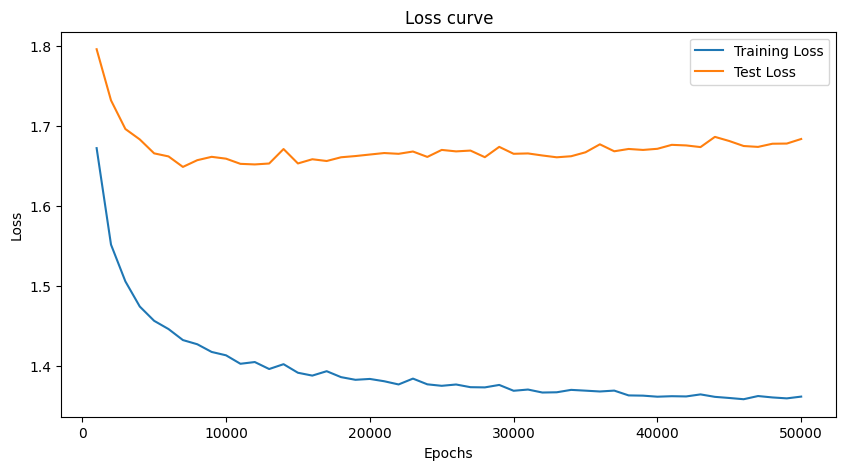

In [9]:
import matplotlib.pyplot as plt

### Visualize loss progression ###

plt.figure(figsize=(10, 5))
plt.plot(epoch_count, train_loss_values, label="Training Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.title("Loss curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [10]:
### Use model ###

@torch.inference_mode()
def evaluate(model, start='\n', length=1000):

    hidden = model.init_hidden()
    prime_input = torch.tensor([[char_to_num[c] for c in start]])

    # Build up hidden state with input text
    for i in range(len(start) - 1):
        _, hidden = model(prime_input[i].to(device), hidden)

    predicted = start

    # Generate new sequence based on hidden state
    input = prime_input[-1]
    for _ in range(length):
        output, hidden = model(input.to(device), hidden)

        probs = F.softmax(output, dim=1)
        ix = torch.multinomial(probs, num_samples=1)[0]

        char = num_to_char[ix.item()]
        predicted += char
        input = ix
    
    return predicted


print(evaluate(model))


I shall sweeted to be abunty, I would I awhile, though this said my headned and not her hand thing upon itself quarrel is't he hour, her opportualting for possess'd twenty some my lord, grows irleot,
Reparr of usurched.

KING RICHARD II:
Helvan on't.

MOPSA:
You may let his durched wither;
By many?
And all to be disdain to the damna,--
Who fall hath shaul years?
Adward's courdly Rome, which through
Thy pride,
And, I can I dirrt-tay let him for you cannot shall patiend a kingdom was the pecraft with'll doubld
O, my wedding way
And, fellow yound.

All:
And not it were guard's chatuo man.

LEONTES:
Why respect, was doundest so?
Farewe's a several, by he;
how no last and lapent:
He authorate! if you being: sir: to decreon,
Like that play your visits,
And at the guest:
Why, sir, when loves hath nigh, as baster of the people
To importale, shall be please,
Which of his lady.

First Servant:
Madam, then lies rishoum.

TRANIO:
Your courtwessurcer:
Livery Bravels,
To kinglo?

Messenger:
Who tru